In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata

/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


The following section is connecting the datasets, the dataset should contain the following columns.
The date time item of the game - pd.datetime
Home team, away team - team names
Home team win - binary 1 for true 0 for false
Home/Away team defensive rankings
- Vs all positions
- Vs different stats
- Overall
Home/Away team offensive rankings
- From all positions
- For different stats
- Overall
Home/Away record
Past 5 as a win percentage
Past 10 as a win percentage
Overall record as win percentage
Disparities
- Offense/defense ranking vs position and stat


In [3]:
import os
os.chdir('/Users/jacobwhiting/NBA-Prediction-Ensemble')
DATA_DIR = os.getenv("DATA_DIR", "data/")

Players_Stats_df = pd.read_csv(os.path.join(DATA_DIR, "PlayerStatistics.csv"))
Player_Info_df   = pd.read_csv(os.path.join(DATA_DIR, "Players.csv"))
Games_df         = pd.read_csv(os.path.join(DATA_DIR, "Games.csv"))
Teams_df         = pd.read_csv(os.path.join(DATA_DIR, "TeamStatistics.csv"))
Players_2022     = pd.read_csv(os.path.join(DATA_DIR, "2022_2023_NBA_Players.csv"))
Players_2023     = pd.read_csv(os.path.join(DATA_DIR, "2023_2024_NBA_Players.csv"))
Players_2024     = pd.read_csv(os.path.join(DATA_DIR, "2024_2025_NBA_Players.csv"))
Players_2025     = pd.read_csv(os.path.join(DATA_DIR, "2025_2026_NBA_Player_Totals.csv"))
NBA_ABBR         = pd.read_csv(os.path.join(DATA_DIR, "NBA_Abbreviations.csv"))

/var/folders/sl/wlpkt3lx5rb8v66x288tmr8c0000gn/T/ipykernel_75065/2139454134.py:5: DtypeWarning: Columns (10,11,15) have mixed types. Specify dtype option on import or set low_memory=False.
  Players_Stats_df = pd.read_csv(os.path.join(DATA_DIR, "PlayerStatistics.csv"))
/var/folders/sl/wlpkt3lx5rb8v66x288tmr8c0000gn/T/ipykernel_75065/2139454134.py:7: DtypeWarning: Columns (12,14,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  Games_df         = pd.read_csv(os.path.join(DATA_DIR, "Games.csv"))


In [4]:
## Team rankings for overall defense, overall offense, in recent years
## Break into home points, home team and away points, away teams 
Games_df['gameDateTimeEst'] = Games_df['gameDateTimeEst'].str.replace(r"[+-]\d{2}:\d{2}$", "", regex=True)
Games_df['gameDateTimeEst'] = pd.to_datetime(Games_df['gameDateTimeEst'], format="%Y-%m-%d %H:%M:%S")
Games_df['season'] = Games_df['gameDateTimeEst'].dt.year
Games_df.loc[
    Games_df['gameDateTimeEst'].dt.month < 10, 'season'
] -= 1
NewGames_df = Games_df[Games_df['season'] >= 2022]
home_offense = (
    NewGames_df
    .groupby(['season', 'hometeamName'])['homeScore']
    .mean()
    .rename('home_offense')
)
away_offense = (
    NewGames_df
    .groupby(['season', 'awayteamName'])['awayScore']
    .mean()
    .rename('away_offense')
)
home_defense = (
    NewGames_df
    .groupby(['season', 'hometeamName'])['awayScore']
    .mean()
    .rename('home_defense')
)
away_defense = (
    NewGames_df
    .groupby(['season', 'awayteamName'])['homeScore']
    .mean()
    .rename('away_defense')
)

In [5]:
home_offense.index = home_offense.index.set_names(['season', 'team'])
away_offense.index = away_offense.index.set_names(['season', 'team'])
home_defense.index = home_defense.index.set_names(['season', 'team'])
away_defense.index = away_defense.index.set_names(['season', 'team'])

team_season_stats = (
    pd.concat(
        [home_offense, away_offense, home_defense, away_defense],
        axis=1
    )
    .reset_index()
)
team_season_stats['overall_offense'] = team_season_stats[
    ['home_offense', 'away_offense']
].mean(axis=1)

team_season_stats['overall_defense'] = team_season_stats[
    ['home_defense', 'away_defense']
].mean(axis=1)
team_season_stats['rank_home_offense'] = (
    team_season_stats
    .groupby('season')['home_offense']
    .rank(ascending=False, method='min')
)

team_season_stats['rank_away_offense'] = (
    team_season_stats
    .groupby('season')['away_offense']
    .rank(ascending=False, method='min')
)

team_season_stats['rank_overall_offense'] = (
    team_season_stats
    .groupby('season')['overall_offense']
    .rank(ascending=False, method='min')
)
team_season_stats['rank_home_defense'] = (
    team_season_stats
    .groupby('season')['home_defense']
    .rank(ascending=True, method='min')
)

team_season_stats['rank_away_defense'] = (
    team_season_stats
    .groupby('season')['away_defense']
    .rank(ascending=True, method='min')
)

team_season_stats['rank_overall_defense'] = (
    team_season_stats
    .groupby('season')['overall_defense']
    .rank(ascending=True, method='min')
)

In [6]:
team_2025_stats = team_season_stats[team_season_stats['season'] == 2025].dropna()
team_2024_stats = team_season_stats[team_season_stats['season'] == 2024].dropna()
team_2023_stats = team_season_stats[team_season_stats['season'] == 2023].dropna()
team_2022_stats = team_season_stats[team_season_stats['season'] == 2022].dropna()


In [7]:
## Create two datasets for each year of offense, and defense team rankings

## 2025 - 2026 team rankings
offense_2025 = team_2025_stats[[
    "team", "rank_home_offense", "rank_away_offense", "rank_overall_offense"
]].rename(columns={
    "rank_home_offense": "team_off_home",
    "rank_away_offense": "team_off_away",
    "rank_overall_offense": "team_off_overall"
})

defense_2025 = team_2025_stats[[
    "team", "rank_home_defense", "rank_away_defense", "rank_overall_defense"
]].rename(columns={
    "rank_home_defense": "opp_def_home",
    "rank_away_defense": "opp_def_away",
    "rank_overall_defense": "opp_def_overall"
})

## 2024 to 2025 team rankings
offense_2024 = team_2024_stats[[
    "team", "rank_home_offense", "rank_away_offense", "rank_overall_offense"
]].rename(columns={
    "rank_home_offense": "team_off_home",
    "rank_away_offense": "team_off_away",
    "rank_overall_offense": "team_off_overall"
})

defense_2024 = team_2024_stats[[
    "team", "rank_home_defense", "rank_away_defense", "rank_overall_defense"
]].rename(columns={
    "rank_home_defense": "opp_def_home",
    "rank_away_defense": "opp_def_away",
    "rank_overall_defense": "opp_def_overall"
})

## 2023 to 2024 team rankings
offense_2023 = team_2023_stats[[
    "team", "rank_home_offense", "rank_away_offense", "rank_overall_offense"
]].rename(columns={
    "rank_home_offense": "team_off_home",
    "rank_away_offense": "team_off_away",
    "rank_overall_offense": "team_off_overall"
})

defense_2023 = team_2023_stats[[
    "team", "rank_home_defense", "rank_away_defense", "rank_overall_defense"
]].rename(columns={
    "rank_home_defense": "opp_def_home",
    "rank_away_defense": "opp_def_away",
    "rank_overall_defense": "opp_def_overall"
})

## 2022 to 2023 team rankings
offense_2022 = team_2022_stats[[
    "team", "rank_home_offense", "rank_away_offense", "rank_overall_offense"
]].rename(columns={
    "rank_home_offense": "team_off_home",
    "rank_away_offense": "team_off_away",
    "rank_overall_offense": "team_off_overall"
})

defense_2022 = team_2022_stats[[
    "team", "rank_home_defense", "rank_away_defense", "rank_overall_defense"
]].rename(columns={
    "rank_home_defense": "opp_def_home",
    "rank_away_defense": "opp_def_away",
    "rank_overall_defense": "opp_def_overall"
})

In [8]:
def normalize_player_name(name):
    if pd.isna(name):
        return name

    # normalize unicode (important for odd punctuation)
    name = unicodedata.normalize("NFKD", str(name))

    # lowercase
    name = name.lower()

    # remove periods and commas
    name = re.sub(r"[.,]", "", name)

    # remove common suffixes (ROBUST)
    name = re.sub(
        r"\s+(jr|sr|ii|iii|iv|v)\s*$",
        "",
        name
    )

    # collapse whitespace
    name = re.sub(r"\s+", " ", name).strip()

    return name

In [9]:
'''
Now, we want to combine the NBA players season stats with the box score dataset, 
we want a full dataset that has the players names, total season stats, position 
for every time the player name appears in box scores
'''
## Here adds a season column to the boxscore dataset
Players_Stats_df['gameDateTimeEst'] = pd.to_datetime(Players_Stats_df['gameDateTimeEst'], errors = 'coerce')
Players_Stats_df['season'] = Players_Stats_df['gameDateTimeEst'].dt.year
Players_Stats_df.loc[
    Players_Stats_df['gameDateTimeEst'].dt.month < 10, 'season'
] -= 1
Recent_Boxscores_df = (
    Players_Stats_df
    .loc[Players_Stats_df['season'] >= 2022]
    .copy()
)
Recent_Boxscores_df['season'] = Recent_Boxscores_df['season'].astype(str)

## Add a season column for the player stats to track what year, and then stack them vertically
Players_2022['season'] = '2022'
Players_2023['season'] = '2023'
Players_2024['season'] = '2024'
Players_2025['season'] = '2025'
All_Players = pd.concat([Players_2022, Players_2023, Players_2024, Players_2025], ignore_index = True)

In [10]:
##Here cleans the player names in case they have additional suffixes
All_Players['player_name_clean'] = (
    All_Players['Player']
    .astype(str)
    .apply(normalize_player_name)
)

Recent_Boxscores_df['player_name_clean'] = (
    Recent_Boxscores_df['firstName'].astype(str) + ' ' +
    Recent_Boxscores_df['lastName'].astype(str)
).apply(normalize_player_name)

In [11]:
## Create a column to merge on of player name, team, and season in both datasets
Recent_Boxscores_df['season'] = Recent_Boxscores_df['season'].astype('float').astype('Int64').astype('str')
All_Players = All_Players.merge(NBA_ABBR, left_on = 'Team', right_on ='ABBR' )
All_Players['fullname team season'] = All_Players['Player'] + All_Players['Team and City'] + All_Players['season']
Recent_Boxscores_df['fullname team season'] = Recent_Boxscores_df['firstName'] + ' ' + Recent_Boxscores_df['lastName'] + Recent_Boxscores_df['playerteamCity'] + ' ' + Recent_Boxscores_df['playerteamName'] + Recent_Boxscores_df['season']
Full_Players_Boxscores = Recent_Boxscores_df.merge(All_Players, how = 'left', on = 'fullname team season')
Full_Players_Boxscores = Full_Players_Boxscores.loc[:, ~Full_Players_Boxscores.columns.duplicated()]

In [12]:
print(Full_Players_Boxscores.columns)

Index(['firstName', 'lastName', 'personId', 'gameId', 'gameDateTimeEst',
       'playerteamCity', 'playerteamName', 'opponentteamCity',
       'opponentteamName', 'gameType', 'gameLabel', 'gameSubLabel',
       'seriesGameNumber', 'win', 'home', 'numMinutes', 'points', 'assists',
       'blocks', 'steals', 'fieldGoalsAttempted', 'fieldGoalsMade',
       'fieldGoalsPercentage', 'threePointersAttempted', 'threePointersMade',
       'threePointersPercentage', 'freeThrowsAttempted', 'freeThrowsMade',
       'freeThrowsPercentage', 'reboundsDefensive', 'reboundsOffensive',
       'reboundsTotal', 'foulsPersonal', 'turnovers', 'plusMinusPoints',
       'season_x', 'player_name_clean_x', 'fullname team season', 'Rk',
       'Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%',
       '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%',
       'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Trp-Dbl',
       'Awards', 'Player-additional', 'season_y',

In [13]:
'''
Here we need to add in the team rankings, for the teams playing, additional four columns
opposing team defense ranking, either home, or away and overall included with the players
team offense ranking either home, or away and overall
'''
Player_Team_Box_df = Full_Players_Boxscores.copy()

# Defensive team identifier
Player_Team_Box_df['def_team'] = Player_Team_Box_df['opponentteamCity'] + ' ' + Player_Team_Box_df['opponentteamName']

# Defensive home/away perspective
Player_Team_Box_df['def_home_away'] = np.where(Player_Team_Box_df['home'] == 1, 'away', 'home')
# Stats allowed
stat_cols = {
    'points': 'points',
    'rebounds': 'reboundsTotal',
    'assists': 'assists'
}

In [14]:
## defensive against each position and overall
df_vspos = Player_Team_Box_df.copy()
df_vspos['Pos_group'] = df_vspos['Pos']

df_vsall = Player_Team_Box_df.copy()
df_vsall['Pos_group'] = 'ALL'

df_rank_vs_base = pd.concat([df_vspos, df_vsall], ignore_index=True)

In [15]:
'''
The below code is to find the defensive rankings for each position against each stat
and the overall defensive ranking against each stat
'''

group_cols = [
    'season_x',
    'def_team',
    'def_home_away',
    'Pos_group',
    'gameId'
]

agg = (
    df_rank_vs_base
    .groupby(group_cols, as_index=False)
    .agg({
        'points': 'sum',
        'reboundsTotal': 'sum',
        'assists': 'sum'
    })
)

agg = (
    agg
    .groupby(['season_x', 'def_team', 'def_home_away', 'Pos_group'], as_index=False)
    .agg({
        'points': 'mean',
        'reboundsTotal': 'mean',
        'assists': 'mean'
    })
)

overall = (
    agg
    .groupby(['season_x', 'def_team', 'Pos_group'], as_index=False)
    .agg({
        'points': 'mean',
        'reboundsTotal': 'mean',
        'assists': 'mean'
    })
)

overall['def_home_away'] = 'both'

agg = pd.concat([agg, overall], ignore_index=True)

In [16]:
'''
Here is forming the dataframe for the stats of interest and creating a ranking for each team 
in each season by taking the mean stats recorded against a team.
'''

for stat in ['points', 'reboundsTotal', 'assists']:
    agg[f'{stat}_def_rank'] = (
        agg
        .groupby(['season_x', 'def_home_away', 'Pos_group'])[stat]
        .rank(method='dense', ascending=True)
    )

defensive_rankings = agg.rename(columns={
    'season_x': 'season',
    'points': 'pts_allowed',
    'reboundsTotal': 'reb_allowed',
    'assists': 'ast_allowed'
}).sort_values(
    ['season', 'def_home_away', 'Pos_group', 'pts_allowed']
)


In [17]:
'''
Here we will do the same process but to detect offensive stats for each player and the 
overall team. Broken down into home and away for all the seasons that are being considered
'''
Player_Team_Box_df = Full_Players_Boxscores.copy()

# offensive team identifier
Player_Team_Box_df['off_team'] = Player_Team_Box_df['playerteamCity'] + ' ' + Player_Team_Box_df['playerteamName']

# offensive home/away perspective
Player_Team_Box_df['off_home_away'] = np.where(Player_Team_Box_df['home'] == 1, 'away', 'home')
# Stats allowed
stat_cols = {
    'points': 'points',
    'rebounds': 'reboundsTotal',
    'assists': 'assists'
}


In [18]:
## offensive against each position and overall
df_forpos = Player_Team_Box_df.copy()
df_forpos['Pos_group'] = df_forpos['Pos']

df_forall = Player_Team_Box_df.copy()
df_forall['Pos_group'] = 'ALL'

df_rank_for_base = pd.concat([df_forpos, df_forall], ignore_index=True)

In [19]:
'''
The below code is to find the offensive rankings for each position against each stat
and the overall defensive ranking against each stat
'''

group_cols = [
    'season_x',
    'off_team',
    'off_home_away',
    'Pos_group',
    'gameId'
]

agg = (
    df_rank_for_base
    .groupby(group_cols, as_index=False)
    .agg({
        'points': 'sum',
        'reboundsTotal': 'sum',
        'assists': 'sum'
    })
)

agg = (
    agg
    .groupby(['season_x', 'off_team', 'off_home_away', 'Pos_group'], as_index=False)
    .agg({
        'points': 'mean',
        'reboundsTotal': 'mean',
        'assists': 'mean'
    })
)

overall = (
    agg
    .groupby(['season_x', 'off_team', 'Pos_group'], as_index=False)
    .agg({
        'points': 'mean',
        'reboundsTotal': 'mean',
        'assists': 'mean'
    })
)

overall['off_home_away'] = 'both'

agg = pd.concat([agg, overall], ignore_index=True)

In [20]:
'''
Here is forming the dataframe for the stats of interest and creating a ranking for each team 
in each season by taking the mean stats recorded against a team.
'''

for stat in ['points', 'reboundsTotal', 'assists']:
    agg[f'{stat}_off_rank'] = (
        agg
        .groupby(['season_x', 'off_home_away', 'Pos_group'])[stat]
        .rank(method='dense', ascending=False)
    )

offensive_rankings = agg.rename(columns={
    'season_x': 'season',
    'points': 'pts_scored',
    'reboundsTotal': 'reb_scored',
    'assists': 'ast_scored'
}).sort_values(
    ['season', 'off_home_away', 'Pos_group', 'pts_scored']
)


In [21]:
Full_Players_Boxscores.columns

Index(['firstName', 'lastName', 'personId', 'gameId', 'gameDateTimeEst',
       'playerteamCity', 'playerteamName', 'opponentteamCity',
       'opponentteamName', 'gameType', 'gameLabel', 'gameSubLabel',
       'seriesGameNumber', 'win', 'home', 'numMinutes', 'points', 'assists',
       'blocks', 'steals', 'fieldGoalsAttempted', 'fieldGoalsMade',
       'fieldGoalsPercentage', 'threePointersAttempted', 'threePointersMade',
       'threePointersPercentage', 'freeThrowsAttempted', 'freeThrowsMade',
       'freeThrowsPercentage', 'reboundsDefensive', 'reboundsOffensive',
       'reboundsTotal', 'foulsPersonal', 'turnovers', 'plusMinusPoints',
       'season_x', 'player_name_clean_x', 'fullname team season', 'Rk',
       'Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%',
       '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%',
       'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Trp-Dbl',
       'Awards', 'Player-additional', 'season_y',

In [22]:
'''
Now we are going to add a column to the boxscores dataset that has the win percentage
for the last 5 home/away and overall games, last home/away 10 games, and the overall season
only consider the last 5 and last 10 home games for a home team and away for away teams
then overall for both
'''

## Lets review each season individually, so the outcomes of last years games will not contribute to the current seasons games
## Need to merge down from players, so that each gameId has two rows
team_games = (
    Full_Players_Boxscores.groupby(['gameId', 'Team and City', 'season_x', 'gameDateTimeEst', 'home'], as_index = False)
    .agg({
        'points' : 'sum',
        'assists' : 'sum',
        'reboundsTotal' : 'sum',
        'win' : 'mean'
    })
)

## Now create a rolling average over the last 5 games, and last 10 games for each team
team_games = team_games.sort_values(by = ['season_x', 'Team and City', 'gameDateTimeEst'])

teamstat_cols = ['points', 'assists', 'reboundsTotal', 'win']

rolling_avgs = (
    team_games.groupby(['season_x', 'Team and City'])[teamstat_cols]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

rolling_avgs_home = (
    team_games[team_games['home'] == 1]
    .groupby(['season_x', 'Team and City'])[teamstat_cols]
    .apply(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    .reset_index(level=[0, 1], drop=True)
)
rolling_avgs_home = rolling_avgs_home.add_suffix('_L5_Home_Avg')

rolling_avgs_away = (
    team_games[team_games['home'] == 0]
    .groupby(['season_x', 'Team and City'])[teamstat_cols]
    .apply(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    .reset_index(level=[0, 1], drop=True)
)
rolling_avgs_away = rolling_avgs_away.add_suffix('_L5_Away_Avg')

rolling_avgs = rolling_avgs.add_suffix('_L5_Avg')
team_games = pd.concat([team_games, rolling_avgs], axis = 1)
team_games = team_games.join(rolling_avgs_home, how = 'left')
team_games = team_games.join(rolling_avgs_away, how = 'left')
team_games = team_games.sort_values( by = ['gameDateTimeEst'])

team_games

,gameId,Team and City,season_x,gameDateTimeEst,home,points,assists,reboundsTotal,win,points_L5_Avg,...,reboundsTotal_L5_Avg,win_L5_Avg,points_L5_Home_Avg,assists_L5_Home_Avg,reboundsTotal_L5_Home_Avg,win_L5_Home_Avg,points_L5_Away_Avg,assists_L5_Away_Avg,reboundsTotal_L5_Away_Avg,win_L5_Away_Avg
1,12200003,Milwaukee Bucks,2022,2022-10-01 20:00:00,1.0,94.0,20.0,47.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,12200003,Memphis Grizzlies,2022,2022-10-01 20:00:00,0.0,104.0,25.0,39.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12200004,Golden State Warriors,2022,2022-10-02 01:00:00,1.0,83.0,22.0,35.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12200004,Washington Wizards,2022,2022-10-02 01:00:00,0.0,77.0,21.0,40.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12200005,Boston Celtics,2022,2022-10-02 13:00:00,1.0,126.0,40.0,50.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9109,22501155,Oklahoma City Thunder,2025,2026-04-07 22:30:00,0.0,108.0,25.0,43.0,1.0,123.6,...,44.4,1.0,NaN,NaN,NaN,NaN,105.2,24.2,45.0,0.8
9110,22501156,Dallas Mavericks,2025,2026-04-07 22:30:00,0.0,70.0,13.0,33.0,0.0,90.0,...,32.0,0.4,NaN,NaN,NaN,NaN,88.4,22.0,31.6,0.4
9108,22501155,Los Angeles Lakers,2025,2026-04-07 22:30:00,1.0,66.0,12.0,31.0,0.0,88.4,...,35.0,0.6,86.8,18.0,35.4,1.0,NaN,NaN,NaN,NaN
9112,22501157,Phoenix Suns,2025,2026-04-07 23:00:00,1.0,105.0,15.0,34.0,0.0,120.6,...,44.0,0.6,117.2,25.2,43.4,0.6,NaN,NaN,NaN,NaN


In [23]:
##Here is the same code to add last ten for a bigger view of potential trends
rolling_avgs_10 = (
    team_games.groupby(['season_x', 'Team and City'])[teamstat_cols]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
)

rolling_avgs_10_home = (
    team_games[team_games['home'] == 1]
    .groupby(['season_x', 'Team and City'])[teamstat_cols]
    .apply(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
    .reset_index(level=[0, 1], drop=True)
)
rolling_avgs_10_home = rolling_avgs_10_home.add_suffix('_L10_Home_Avg')

rolling_avgs_10_away = (
    team_games[team_games['home'] == 0]
    .groupby(['season_x', 'Team and City'])[teamstat_cols]
    .apply(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
    .reset_index(level=[0, 1], drop=True)
)
rolling_avgs_10_away = rolling_avgs_10_away.add_suffix('_L10_Away_Avg')

rolling_avgs_10 = rolling_avgs_10.add_suffix('_L10_Avg')
team_games = pd.concat([team_games, rolling_avgs_10], axis = 1)
team_games = team_games.join(rolling_avgs_10_home, how = 'left')
team_games = team_games.join(rolling_avgs_10_away, how = 'left')
team_games = team_games.sort_values( by = ['gameDateTimeEst'])

team_games.columns

Index(['gameId', 'Team and City', 'season_x', 'gameDateTimeEst', 'home',
       'points', 'assists', 'reboundsTotal', 'win', 'points_L5_Avg',
       'assists_L5_Avg', 'reboundsTotal_L5_Avg', 'win_L5_Avg',
       'points_L5_Home_Avg', 'assists_L5_Home_Avg',
       'reboundsTotal_L5_Home_Avg', 'win_L5_Home_Avg', 'points_L5_Away_Avg',
       'assists_L5_Away_Avg', 'reboundsTotal_L5_Away_Avg', 'win_L5_Away_Avg',
       'points_L10_Avg', 'assists_L10_Avg', 'reboundsTotal_L10_Avg',
       'win_L10_Avg', 'points_L10_Home_Avg', 'assists_L10_Home_Avg',
       'reboundsTotal_L10_Home_Avg', 'win_L10_Home_Avg', 'points_L10_Away_Avg',
       'assists_L10_Away_Avg', 'reboundsTotal_L10_Away_Avg',
       'win_L10_Away_Avg'],
      dtype='object')

In [24]:
## Here we need to merge the defensive and offensive rankings with the data set. Simply done using season and team name
## However, need to melt so each season and team only have one row
off_rank_pivoted = offensive_rankings.pivot_table(
    index=['season', 'off_team'],
    columns=['off_home_away', 'Pos_group'],
    values=['pts_scored', 'reb_scored', 'ast_scored', 
            'points_off_rank', 'reboundsTotal_off_rank', 'assists_off_rank'],
    aggfunc = 'mean'
).reset_index()

# Flatten the multi-level column names
# This will create column names like: pts_scored_home_PG, pts_scored_away_C, etc.
off_rank_pivoted.columns = ['_'.join(str(col) for col in cols).strip('_') if cols[1] else cols[0] 
                       for cols in off_rank_pivoted.columns.values]
off_team_games = team_games.merge(
    off_rank_pivoted,
    left_on=['season_x', 'Team and City'],
    right_on=['season', 'off_team'],
    how='left'
)


def_rank_pivoted = defensive_rankings.pivot_table(
    index=['season', 'def_team'],
    columns=['def_home_away', 'Pos_group'],
    values=['pts_allowed', 'reb_allowed', 'ast_allowed', 
            'points_def_rank', 'reboundsTotal_def_rank', 'assists_def_rank']
).reset_index()

# Flatten the multi-level column names
# This will create column names like: pts_scored_home_PG, pts_scored_away_C, etc.
def_rank_pivoted.columns = ['_'.join(str(col) for col in cols).strip('_') if cols[1] else cols[0] 
                       for cols in def_rank_pivoted.columns.values]
def_team_games = team_games.merge(
    def_rank_pivoted,
    left_on=['season_x', 'Team and City'],
    right_on=['season', 'def_team'],
    how='left'
)

In [25]:
all_ranking_cols = [col for col in off_team_games.columns if '_rank' in col]

# Extract unique stat_position combinations
import re
stat_position_combos = set()
for col in all_ranking_cols:
    match = re.search(r'(.+)_(home|away|both)_(.+)', col)
    if match:
        stat_name = match.group(1)
        pos_group = match.group(3)
        stat_position_combos.add((stat_name, pos_group))

# Create unified columns using vectorized operations
for stat_name, pos_group in sorted(stat_position_combos):
    home_col = f"{stat_name}_home_{pos_group}"
    away_col = f"{stat_name}_away_{pos_group}"
    new_col = f"{stat_name}_{pos_group}"
    
    if home_col in off_team_games.columns and away_col in off_team_games.columns:
        # Vectorized: use np.where instead of apply
        off_team_games[new_col] = np.where(
            off_team_games['home'] == 1,
            off_team_games[home_col],
            off_team_games[away_col]
        )

In [26]:
all_def_ranking_cols = [col for col in def_team_games.columns if '_rank' in col]

# Extract unique stat_position combinations
import re
stat_position_combos = set()
for col in all_ranking_cols:
    match = re.search(r'(.+)_(home|away|both)_(.+)', col)
    if match:
        stat_name = match.group(1)
        pos_group = match.group(3)
        stat_position_combos.add((stat_name, pos_group))

# Create unified columns using vectorized operations
for stat_name, pos_group in sorted(stat_position_combos):
    home_col = f"{stat_name}_home_{pos_group}"
    away_col = f"{stat_name}_away_{pos_group}"
    new_col = f"{stat_name}_{pos_group}"
    
    if home_col in def_team_games.columns and away_col in def_team_games.columns:
        # Vectorized: use np.where instead of apply
        off_team_games[new_col] = np.where(
            off_team_games['home'] == 1,
            off_team_games[home_col],
            off_team_games[away_col]
        )

In [27]:
Full_DF = off_team_games.merge(
    def_team_games,
    on=['gameId', 'Team and City', 'season_x', 'gameDateTimeEst', 'home'],
    how='inner',  # or 'left' if you want to keep all games from off_team_games
    suffixes=('_off', '_def')  # Add suffixes to overlapping columns
)


In [28]:
team_df = Full_DF.copy()
opponent_df = Full_DF.copy()

# Rename ALL columns in opponent_df except the join keys
join_keys = ['gameId', 'season_x', 'gameDateTimeEst']
for col in opponent_df.columns:
    if col not in join_keys:
        opponent_df.rename(columns={col: f'opp_{col}'}, inplace=True)

Final_DF = team_df.merge(
    opponent_df,
    on=join_keys,
    how='left'
)


Final_DF = Final_DF[Final_DF['home'] != Final_DF['opp_home']]
Final_DF = Final_DF.dropna(subset=['points_off', 'opp_points_off'])
Final_DF['win_off'] = (Final_DF['points_off'] > Final_DF['opp_points_off'])

Below is the logistic regression to predict the likelihood of a team winning based on the columns in the dataset

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix


In [31]:
ranking_cols = [col for col in Final_DF.columns if '_rank' in col]
L5_cols = [col for col in Final_DF.columns if 'L5' in col]
L10_cols = [col for col in Final_DF.columns if 'L10' in col]
X_lr = Final_DF[ranking_cols + L5_cols + L10_cols + ['home']].copy()
Y_lr = Final_DF['win_off']
Y_lr = Y_lr.dropna()
X_lr = X_lr.fillna(X_lr.mean())

In [32]:
X_lr_train, X_lr_test, Y_lr_train, Y_lr_test = train_test_split(
    X_lr, Y_lr, test_size = 0.3, random_state = 67
)

In [33]:
lasso_logreg_model = LogisticRegressionCV(
    cv=5,
    penalty='l1',
    solver='saga',
    max_iter=10000,
    tol = 1e-3,
    random_state=41,
    scoring='neg_log_loss'
)

scaler = StandardScaler()
X_lr_train_scaled = scaler.fit_transform(X_lr_train)
X_lr_test_scaled = scaler.transform(X_lr_test)

lasso_logreg_model.fit(X_lr_train_scaled, Y_lr_train)


selected_features = X_lr_train.columns[lasso_logreg_model.coef_[0] != 0].tolist()

print(f"\nLASSO selected {len(selected_features)} features:")
print(selected_features)

Y_lr_pred_proba = lasso_logreg_model.predict_proba(X_lr_test_scaled)[:, 1]
Y_lr_pred = lasso_logreg_model.predict(X_lr_test_scaled)

print("\nModel Performance:")
print(f"Accuracy: {accuracy_score(Y_lr_test, Y_lr_pred):.3f}")
print(f"AUC-ROC: {roc_auc_score(Y_lr_test, Y_lr_pred_proba):.3f}")

/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_leg


LASSO selected 117 features:
['assists_off_rank_away_PF', 'assists_off_rank_home_PF', 'points_off_rank_away_ALL', 'points_off_rank_away_C', 'points_off_rank_both_ALL', 'points_off_rank_home_PG', 'reboundsTotal_off_rank_away_PF', 'reboundsTotal_off_rank_away_SF', 'reboundsTotal_off_rank_home_SG', 'assists_off_rank_PF', 'reboundsTotal_off_rank_ALL', 'assists_def_rank_away_C', 'assists_def_rank_away_PF', 'assists_def_rank_both_C', 'assists_def_rank_both_SF', 'points_def_rank_away_ALL', 'points_def_rank_away_C', 'points_def_rank_both_ALL', 'points_def_rank_both_C', 'points_def_rank_both_SG', 'points_def_rank_home_ALL', 'points_def_rank_home_PF', 'points_def_rank_home_PG', 'points_def_rank_home_SG', 'reboundsTotal_def_rank_away_C', 'reboundsTotal_def_rank_away_PG', 'reboundsTotal_def_rank_away_SG', 'reboundsTotal_def_rank_both_PG', 'reboundsTotal_def_rank_both_SG', 'opp_assists_off_rank_home_PF', 'opp_points_off_rank_away_ALL', 'opp_points_off_rank_away_C', 'opp_points_off_rank_away_PG', '

In [34]:
ridge_logreg_model = LogisticRegressionCV(
    cv=5,
    penalty='l2',
    solver='lbfgs',
    max_iter=10000,
    tol=1e-3,
    random_state=41,
    scoring='neg_brier_score'
)
scaler = StandardScaler()
X_lr_train_scaled = scaler.fit_transform(X_lr_train)
X_lr_test_scaled = scaler.transform(X_lr_test)
ridge_logreg_model.fit(X_lr_train_scaled, Y_lr_train)

# Ridge doesn't zero out coefficients like Lasso, so this will show all features
# You could instead show features sorted by absolute coefficient magnitude
coefficients = pd.DataFrame({
    'feature': X_lr_train.columns,
    'coefficient': ridge_logreg_model.coef_[0]
})
coefficients['abs_coef'] = coefficients['coefficient'].abs()
coefficients = coefficients.sort_values('abs_coef', ascending=False)

print(f"\nTop 20 most important features by Ridge coefficient magnitude:")
print(coefficients.head(20))

Y_lr_pred_proba = ridge_logreg_model.predict_proba(X_lr_test_scaled)[:, 1]
Y_lr_pred = ridge_logreg_model.predict(X_lr_test_scaled)
print("\nModel Performance:")
print(f"Accuracy: {accuracy_score(Y_lr_test, Y_lr_pred):.3f}")
print(f"AUC-ROC: {roc_auc_score(Y_lr_test, Y_lr_pred_proba):.3f}")

/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_leg


Top 20 most important features by Ridge coefficient magnitude:
                            feature  coefficient  abs_coef
348                            home     0.182149  0.182149
252               points_L5_Avg_off     0.126346  0.126346
264               points_L5_Avg_def     0.126346  0.126346
276           opp_points_L5_Avg_off    -0.109521  0.109521
288           opp_points_L5_Avg_def    -0.109521  0.109521
90         points_def_rank_away_ALL    -0.109203  0.109203
24         points_off_rank_both_ALL    -0.104183  0.104183
150    opp_points_off_rank_both_ALL     0.097758  0.097758
228    opp_points_def_rank_home_ALL     0.094401  0.094401
18         points_off_rank_away_ALL    -0.092240  0.092240
96         points_def_rank_both_ALL    -0.090933  0.090933
268          points_L5_Home_Avg_def     0.082060  0.082060
256          points_L5_Home_Avg_off     0.082060  0.082060
156    opp_points_off_rank_home_ALL     0.081058  0.081058
216    opp_points_def_rank_away_ALL     0.079717  0

Below is the XGBoost for predicting outcome of games

In [36]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

Here, for the XGBoost, the data is going to be interpreted as the difference between each team for a particular stat; for example, instead of two columns for L5_points_scored and L5_points_allowed, there will be a L5 point differential. Similarly, there will be a comparison between the rankings. The more negative indicates a larger the mismatch in favor of the team. The more positive indicates that a team is outmatched by opponent.

In [38]:
cols_to_drop = [col for col in Final_DF.columns if ('rank' in col or 'allowed' in col or 'scored' in col) and 'ALL' not in col]

Filtered_Final_DF = Final_DF.drop(columns = cols_to_drop)

In [39]:
'''
Need to edit this to properly compare all of the stats in the filtered_final_DF
It is only creating three differential features as of now. Need it to have the 
differential for every stat and correctly compare offense and defense matchups
Need to pair opp away with team home and vice versa
'''

def create_differential_features(df):
    """
    Create comparison/differential columns for NBA matchup analysis.
    Focuses on team vs opponent differentials rather than separate columns.
    """
    
    # Make a copy to avoid modifying original
    df_diff = df.copy()

    # L5 Differentials
    df_diff['home_away_reb_diff_L5'] = (
        df_diff['opp_reboundsTotal_L5_Home_Avg_off'] - 
        df_diff['reboundsTotal_L5_Away_Avg_off']
    )
    df_diff['home_away_pts_diff_L5'] = (
        df_diff['opp_points_L5_Home_Avg_off'] - 
        df_diff['points_L5_Away_Avg_off']
    )
    df_diff['home_away_ast_diff_L5'] = (
        df_diff['opp_assists_L5_Home_Avg_off'] - 
        df_diff['assists_L5_Away_Avg_off']
    )
    df_diff['home_away_win_diff_L5'] = (
        df_diff['opp_win_L5_Home_Avg_off'] - 
        df_diff['win_L5_Away_Avg_off']
    )
    
    # L10 Differentials
    df_diff['home_away_reb_diff_L10'] = (
        df_diff['opp_reboundsTotal_L10_Home_Avg_off'] - 
        df_diff['reboundsTotal_L10_Away_Avg_off']
    )
    df_diff['home_away_pts_diff_L10'] = (
        df_diff['opp_points_L10_Home_Avg_off'] - 
        df_diff['points_L10_Away_Avg_off']
    )
    df_diff['home_away_ast_diff_L10'] = (
        df_diff['opp_assists_L10_Home_Avg_off'] - 
        df_diff['assists_L10_Away_Avg_off']
    )
    df_diff['home_away_win_diff_L10'] = (
        df_diff['opp_win_L10_Home_Avg_off'] - 
        df_diff['win_L10_Away_Avg_off']
    )
    
    # L5 Overall Differentials
    df_diff['overall_reb_diff_L5'] = (
        df_diff['opp_reboundsTotal_L5_Avg_off'] - 
        df_diff['reboundsTotal_L5_Avg_off']
    )
    df_diff['overall_pts_diff_L5'] = (
        df_diff['opp_points_L5_Avg_off'] - 
        df_diff['points_L5_Avg_off']
    )
    df_diff['overall_ast_diff_L5'] = (
        df_diff['opp_assists_L5_Avg_off'] - 
        df_diff['assists_L5_Avg_off']
    )
    df_diff['overall_win_diff_L5'] = (
        df_diff['opp_win_L5_Avg_off'] - 
        df_diff['win_L5_Avg_off']
    )
    
    # L10 Overall Differentials
    df_diff['overall_reb_diff_L10'] = (
        df_diff['opp_reboundsTotal_L10_Avg_off'] - 
        df_diff['reboundsTotal_L10_Avg_off']
    )
    df_diff['overall_pts_diff_L10'] = (
        df_diff['opp_points_L10_Avg_off'] - 
        df_diff['points_L10_Avg_off']
    )
    df_diff['overall_ast_diff_L10'] = (
        df_diff['opp_assists_L10_Avg_off'] - 
        df_diff['assists_L10_Avg_off']
    )
    df_diff['overall_win_diff_L10'] = (
        df_diff['opp_win_L10_Avg_off'] - 
        df_diff['win_L10_Avg_off']
    )
    # When team is AWAY (most common scenario based on your example)
    df_diff['team_pts_vs_opp_def_away'] = (
        df_diff['pts_scored_away_ALL'] - 
        df_diff['opp_pts_allowed_home_ALL']
    )
    df_diff['team_ast_vs_opp_def_away'] = (
        df_diff['ast_scored_away_ALL'] - 
        df_diff['opp_ast_allowed_home_ALL']
    )
    df_diff['team_reb_vs_opp_def_away'] = (
        df_diff['reb_scored_away_ALL'] - 
        df_diff['opp_reb_allowed_home_ALL']
    )
    
    # When team is HOME
    df_diff['team_pts_vs_opp_def_home'] = (
        df_diff['pts_scored_home_ALL'] - 
        df_diff['opp_pts_allowed_away_ALL']
    )
    df_diff['team_ast_vs_opp_def_home'] = (
        df_diff['ast_scored_home_ALL'] - 
        df_diff['opp_ast_allowed_away_ALL']
    )
    df_diff['team_reb_vs_opp_def_home'] = (
        df_diff['reb_scored_home_ALL'] - 
        df_diff['opp_reb_allowed_away_ALL']
    )
    
    # Overall (both home and away combined)
    df_diff['team_pts_vs_opp_def_both'] = (
        df_diff['pts_scored_both_ALL'] - 
        df_diff['opp_pts_allowed_both_ALL']
    )
    df_diff['team_ast_vs_opp_def_both'] = (
        df_diff['ast_scored_both_ALL'] - 
        df_diff['opp_ast_allowed_both_ALL']
    )
    df_diff['team_reb_vs_opp_def_both'] = (
        df_diff['reb_scored_both_ALL'] - 
        df_diff['opp_reb_allowed_both_ALL']
    )
    
    # Opponent's offensive capability vs Team's defensive capability
    df_diff['opp_pts_vs_team_def_home'] = (
        df_diff['opp_pts_scored_home_ALL'] - 
        df_diff['pts_allowed_away_ALL']
    )
    df_diff['opp_ast_vs_team_def_home'] = (
        df_diff['opp_ast_scored_home_ALL'] - 
        df_diff['ast_allowed_away_ALL']
    )
    df_diff['opp_reb_vs_team_def_home'] = (
        df_diff['opp_reb_scored_home_ALL'] - 
        df_diff['reb_allowed_away_ALL']
    )
    
    df_diff['opp_pts_vs_team_def_away'] = (
        df_diff['opp_pts_scored_away_ALL'] - 
        df_diff['pts_allowed_home_ALL']
    )
    df_diff['opp_ast_vs_team_def_away'] = (
        df_diff['opp_ast_scored_away_ALL'] - 
        df_diff['ast_allowed_home_ALL']
    )
    df_diff['opp_reb_vs_team_def_away'] = (
        df_diff['opp_reb_scored_away_ALL'] - 
        df_diff['reb_allowed_home_ALL']
    )
    
    df_diff['opp_pts_vs_team_def_both'] = (
        df_diff['opp_pts_scored_both_ALL'] - 
        df_diff['pts_allowed_both_ALL']
    )
    df_diff['opp_ast_vs_team_def_both'] = (
        df_diff['opp_ast_scored_both_ALL'] - 
        df_diff['ast_allowed_both_ALL']
    )
    df_diff['opp_reb_vs_team_def_both'] = (
        df_diff['opp_reb_scored_both_ALL'] - 
        df_diff['reb_allowed_both_ALL']
    )
    
    # Team's offensive rank vs Opponent's defensive rank
    df_diff['team_off_vs_opp_def_pts_rank'] = (
        df_diff['points_off_rank_ALL'] - 
        df_diff['opp_points_def_rank_both_ALL']
    )
    df_diff['team_off_vs_opp_def_ast_rank'] = (
        df_diff['assists_off_rank_ALL'] - 
        df_diff['opp_assists_def_rank_both_ALL']
    )
    df_diff['team_off_vs_opp_def_reb_rank'] = (
        df_diff['reboundsTotal_off_rank_ALL'] - 
        df_diff['opp_reboundsTotal_def_rank_both_ALL']
    )
    
    # Opponent's offensive rank vs Team's defensive rank
    df_diff['opp_off_vs_team_def_pts_rank'] = (
        df_diff['opp_points_off_rank_ALL'] - 
        df_diff['points_def_rank_both_ALL']
    )
    df_diff['opp_off_vs_team_def_ast_rank'] = (
        df_diff['opp_assists_off_rank_ALL'] - 
        df_diff['assists_def_rank_both_ALL']
    )
    df_diff['opp_off_vs_team_def_reb_rank'] = (
        df_diff['opp_reboundsTotal_off_rank_ALL'] - 
        df_diff['reboundsTotal_def_rank_both_ALL']
    )
    
    # Location-specific rank differentials
    df_diff['team_off_vs_opp_def_pts_rank_away'] = (
        df_diff['points_off_rank_away_ALL'] - 
        df_diff['opp_points_def_rank_home_ALL']
    )
    df_diff['team_off_vs_opp_def_pts_rank_home'] = (
        df_diff['points_off_rank_home_ALL'] - 
        df_diff['opp_points_def_rank_away_ALL']
    )
    
    # Current game performance differential
    df_diff['current_pts_diff'] = df_diff['points_off'] - df_diff['opp_points_off']
    df_diff['current_ast_diff'] = df_diff['assists_off'] - df_diff['opp_assists_off']
    df_diff['current_reb_diff'] = df_diff['reboundsTotal_off'] - df_diff['opp_reboundsTotal_off']
    
    # Defensive performance differential (points/assists/rebounds allowed)
    df_diff['def_pts_diff_L5'] = df_diff['points_L5_Avg_def'] - df_diff['opp_points_L5_Avg_def']
    df_diff['def_ast_diff_L5'] = df_diff['assists_L5_Avg_def'] - df_diff['opp_assists_L5_Avg_def']
    df_diff['def_reb_diff_L5'] = df_diff['reboundsTotal_L5_Avg_def'] - df_diff['opp_reboundsTotal_L5_Avg_def']
    
    df_diff['def_pts_diff_L10'] = df_diff['points_L10_Avg_def'] - df_diff['opp_points_L10_Avg_def']
    df_diff['def_ast_diff_L10'] = df_diff['assists_L10_Avg_def'] - df_diff['opp_assists_L10_Avg_def']
    df_diff['def_reb_diff_L10'] = df_diff['reboundsTotal_L10_Avg_def'] - df_diff['opp_reboundsTotal_L10_Avg_def']
     
    return df_diff

df_enhanced = create_differential_features(Filtered_Final_DF)


In [40]:
xgb_exclude_cols = [
    'gameId', 'Team and City', 'season_x', 'gameDateTimeEst', 
    'off_team', 'def_team', 'season_off', 'season_def',
    'opp_Team and City', 'opp_off_team', 'opp_def_team', 
    'opp_season_off', 'opp_season_def', 'current_pts_diff', 'current_asts_diff',
    'win_off',  'current_ast_diff', 'current_reb_diff', 'points_off',
    'assists_off', 'reboundsTotal_off', 'points_def', 'assists_def', 'reboundsTotal_def',
    'opp_points_off', 'opp_assists_off', 'opp_reboundsTotal_off', 'opp_points_def',
    'opp_assists_def', 'opp_reboundsTotal_def',
    'win_def', 'opp_win_off', 'opp_win_def'
    ]

xgb_feature_cols = [col for col in df_enhanced.columns if col not in xgb_exclude_cols]

X_xgb = df_enhanced[xgb_feature_cols].copy()
Y_xgb = df_enhanced['win_off'].copy()

X_xgb_train, X_xgb_test, Y_xgb_train, Y_xgb_test = train_test_split(
        X_xgb, Y_xgb, test_size=0.3, random_state=67, stratify=Y_xgb
    )

xgbmodel = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=41,
        eval_metric='logloss',
        early_stopping_rounds=10
    )

xgbmodel.fit(
        X_xgb_train, Y_xgb_train,
        eval_set=[(X_xgb_test, Y_xgb_test)],
        verbose=False
    )


Y_xgb_train_pred = xgbmodel.predict(X_xgb_train)
Y_xgb_test_pred = xgbmodel.predict(X_xgb_test)
    
    # Probabilities for AUC
Y_xgb_train_proba = xgbmodel.predict_proba(X_xgb_train)[:, 1]
Y_xgb_test_proba = xgbmodel.predict_proba(X_xgb_test)[:, 1]
    
    # Calculate metrics
train_acc = accuracy_score(Y_xgb_train, Y_xgb_train_pred)
test_acc = accuracy_score(Y_xgb_test, Y_xgb_test_pred)
train_auc = roc_auc_score(Y_xgb_train, Y_xgb_train_proba)
test_auc = roc_auc_score(Y_xgb_test, Y_xgb_test_proba)

In [41]:
print(f"\nAccuracy Scores:")
print(f"  Training Accuracy: {train_acc:.4f}")
print(f"  Test Accuracy:     {test_acc:.4f}")
print(f"\nAUC Scores:")
print(f"  Training AUC: {train_auc:.4f}")
print(f"  Test AUC:     {test_auc:.4f}")
    
    # Classification report
print(f"\n" + "-"*70)
print("Classification Report (Test Set):")
print("-"*70)
print(classification_report(Y_xgb_test, Y_xgb_test_pred, target_names=['Loss', 'Win']))

# Confusion matrix
print("\n" + "-"*70)
print("Confusion Matrix (Test Set):")
print("-"*70)
cm = confusion_matrix(Y_xgb_test, Y_xgb_test_pred)
print(f"\n{cm}")
print(f"\nTrue Negatives:  {cm[0,0]} | False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]} | True Positives:  {cm[1,1]}")



Accuracy Scores:
  Training Accuracy: 0.8516
  Test Accuracy:     0.7260

AUC Scores:
  Training AUC: 0.9340
  Test AUC:     0.7965

----------------------------------------------------------------------
Classification Report (Test Set):
----------------------------------------------------------------------
              precision    recall  f1-score   support

        Loss       0.72      0.74      0.73      1315
         Win       0.73      0.71      0.72      1284

    accuracy                           0.73      2599
   macro avg       0.73      0.73      0.73      2599
weighted avg       0.73      0.73      0.73      2599


----------------------------------------------------------------------
Confusion Matrix (Test Set):
----------------------------------------------------------------------

[[972 343]
 [369 915]]

True Negatives:  972 | False Positives: 343
False Negatives: 369 | True Positives:  915


In [42]:
def plot_feature_importance(model, feature_cols, top_n=20):
    """
    Plot top N most important features.
    """
    # Get feature importance
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Plot top N
    plt.figure(figsize=(10, 8))
    top_features = importance_df.head(top_n)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Top {top_n} Most Important Features')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print(f"\n" + "="*70)
    print(f"Top {top_n} Most Important Features:")
    print("="*70)
    for idx, row in top_features.iterrows():
        print(f"{row['feature']:50s} {row['importance']:.6f}")
    
    return importance_df

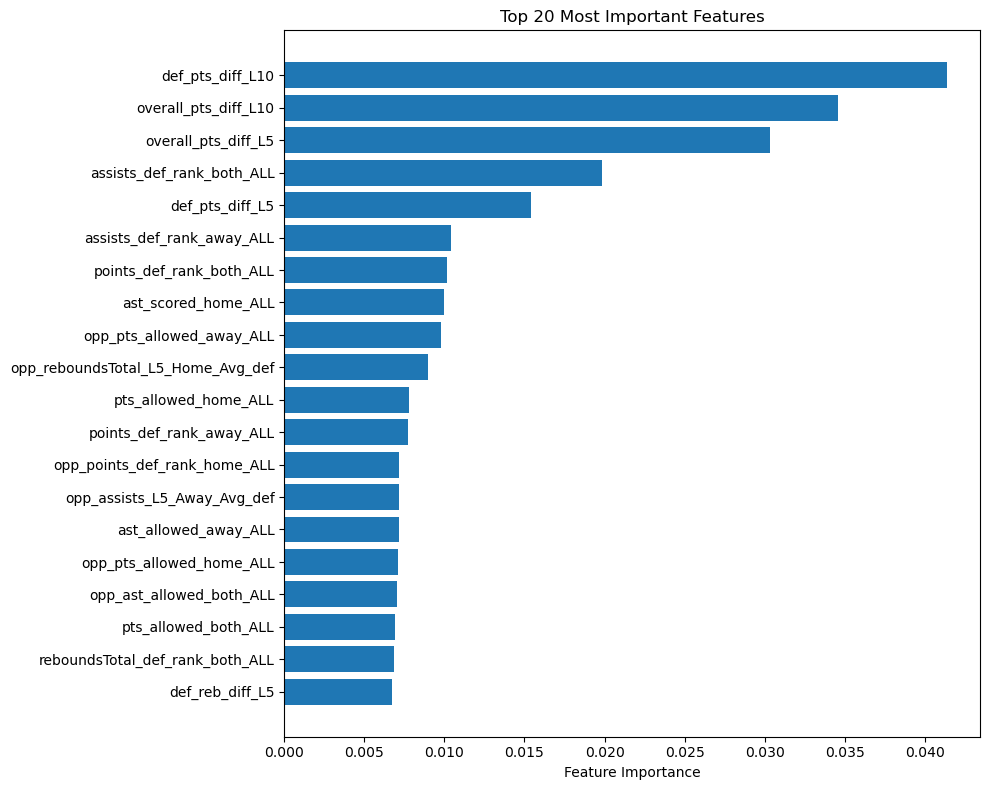


Top 20 Most Important Features:
def_pts_diff_L10                                   0.041370
overall_pts_diff_L10                               0.034557
overall_pts_diff_L5                                0.030338
assists_def_rank_both_ALL                          0.019809
def_pts_diff_L5                                    0.015429
assists_def_rank_away_ALL                          0.010391
points_def_rank_both_ALL                           0.010132
ast_scored_home_ALL                                0.009977
opp_pts_allowed_away_ALL                           0.009799
opp_reboundsTotal_L5_Home_Avg_def                  0.008992
pts_allowed_home_ALL                               0.007803
points_def_rank_away_ALL                           0.007733
opp_points_def_rank_home_ALL                       0.007165
opp_assists_L5_Away_Avg_def                        0.007143
ast_allowed_away_ALL                               0.007139
opp_pts_allowed_home_ALL                           0.007074
opp_ast

,feature,importance
221,def_pts_diff_L10,0.041370
189,overall_pts_diff_L10,0.034557
185,overall_pts_diff_L5,0.030338
71,assists_def_rank_both_ALL,0.019809
218,def_pts_diff_L5,0.015429
...,...,...
149,opp_win_L10_Avg_def,0.000000
88,opp_home,0.000000
57,win_L5_Away_Avg_def,0.000000
55,assists_L5_Away_Avg_def,0.000000


In [43]:
plot_feature_importance(xgbmodel, xgb_feature_cols)

Having completed two logistic regression models as well as an XGBoost, we will combine them in an ensemble below

In [45]:
lr_exclude_cols = [
    'gameId', 'Team and City', 'season_x', 'gameDateTimeEst', 
    'off_team', 'def_team', 'season_off', 'season_def',
    'opp_Team and City', 'opp_off_team', 'opp_def_team', 
    'opp_season_off', 'opp_season_def', 'current_pts_diff', 'current_asts_diff',
    'win_off',  'current_ast_diff', 'current_reb_diff', 'points_off',
    'assists_off', 'reboundsTotal_off', 'points_def', 'assists_def', 'reboundsTotal_def',
    'opp_points_off', 'opp_assists_off', 'opp_reboundsTotal_off', 'opp_points_def',
    'opp_assists_def', 'opp_reboundsTotal_def',
    'win_def', 'opp_win_off', 'opp_win_def',
    'def_pts_diff_L5', 'def_ast_diff_L5', 'def_reb_diff_L5',
    'def_pts_diff_L10', 'def_ast_diff_L10', 'def_reb_diff_L10',
    'team_off_vs_opp_def_pts_rank_away', 'team_off_vs_opp_def_pts_rank_home',
    'opp_off_vs_team_def_pts_rank', 'opp_off_vs_team_def_ast_rank', 
    'opp_off_vs_team_def_reb_rank',
    'team_off_vs_opp_def_pts_rank', 'team_off_vs_opp_def_ast_rank', 
    'team_off_vs_opp_def_reb_rank',
    'opp_pts_vs_team_def_both', 'opp_ast_vs_team_def_both', 'opp_reb_vs_team_def_both',
    'opp_pts_vs_team_def_away', 'opp_ast_vs_team_def_away', 'opp_reb_vs_team_def_away',
    'opp_pts_vs_team_def_home', 'opp_ast_vs_team_def_home', 'opp_reb_vs_team_def_home',
    'team_pts_vs_opp_def_both', 'team_ast_vs_opp_def_both', 'team_reb_vs_opp_def_both',
    'team_pts_vs_opp_def_away', 'team_ast_vs_opp_def_away', 'team_reb_vs_opp_def_away',
    'team_pts_vs_opp_def_home', 'team_ast_vs_opp_def_home', 'team_reb_vs_opp_def_home',
    'points_L5_Home_Avg_off', 'assists_L5_Home_Avg_off', 'reboundsTotal_L5_Home_Avg_off', 
    'win_L5_Home_Avg_off', 'points_L5_Away_Avg_off', 'assists_L5_Away_Avg_off', 
    'reboundsTotal_L5_Away_Avg_off', 'win_L5_Away_Avg_off', 
    'points_L10_Home_Avg_off', 'assists_L10_Home_Avg_off', 'reboundsTotal_L10_Home_Avg_off', 
    'win_L10_Home_Avg_off', 'points_L10_Away_Avg_off', 'assists_L10_Away_Avg_off', 
    'reboundsTotal_L10_Away_Avg_off', 'win_L10_Away_Avg_off', 'win_def',
    'points_L5_Home_Avg_def', 'assists_L5_Home_Avg_def', 'reboundsTotal_L5_Home_Avg_def', 
    'win_L5_Home_Avg_def', 'points_L5_Away_Avg_def', 'assists_L5_Away_Avg_def', 
    'reboundsTotal_L5_Away_Avg_def', 'win_L5_Away_Avg_def', 
    'points_L10_Home_Avg_def', 'assists_L10_Home_Avg_def', 'reboundsTotal_L10_Home_Avg_def', 
    'win_L10_Home_Avg_def', 'points_L10_Away_Avg_def', 'assists_L10_Away_Avg_def', 
    'reboundsTotal_L10_Away_Avg_def', 'win_L10_Away_Avg_def', 'opp_win_off', 
    'opp_points_L5_Home_Avg_off', 'opp_assists_L5_Home_Avg_off', 
    'opp_reboundsTotal_L5_Home_Avg_off', 'opp_win_L5_Home_Avg_off', 
    'opp_points_L5_Away_Avg_off', 'opp_assists_L5_Away_Avg_off', 
    'opp_reboundsTotal_L5_Away_Avg_off', 'opp_win_L5_Away_Avg_off', 
    'opp_points_L10_Home_Avg_off', 'opp_assists_L10_Home_Avg_off', 
    'opp_reboundsTotal_L10_Home_Avg_off', 'opp_win_L10_Home_Avg_off', 
    'opp_points_L10_Away_Avg_off', 'opp_assists_L10_Away_Avg_off', 
    'opp_reboundsTotal_L10_Away_Avg_off', 'opp_win_L10_Away_Avg_off', 
    'opp_points_L5_Home_Avg_def', 'opp_assists_L5_Home_Avg_def', 
    'opp_reboundsTotal_L5_Home_Avg_def', 'opp_win_L5_Home_Avg_def', 
    'opp_points_L5_Away_Avg_def', 'opp_assists_L5_Away_Avg_def', 
    'opp_reboundsTotal_L5_Away_Avg_def', 'opp_win_L5_Away_Avg_def', 
    'opp_points_L10_Home_Avg_def', 'opp_assists_L10_Home_Avg_def', 
    'opp_reboundsTotal_L10_Home_Avg_def', 'opp_win_L10_Home_Avg_def', 
    'opp_points_L10_Away_Avg_def', 'opp_assists_L10_Away_Avg_def', 
    'opp_reboundsTotal_L10_Away_Avg_def', 'opp_win_L10_Away_Avg_def', 
    'home_away_reb_diff_L5', 'home_away_pts_diff_L5', 'home_away_ast_diff_L5', 
    'home_away_win_diff_L5', 'home_away_reb_diff_L10', 'home_away_pts_diff_L10', 
    'home_away_ast_diff_L10', 'home_away_win_diff_L10', 'overall_reb_diff_L5'
]

lr_feature_cols = [col for col in df_enhanced.columns if col not in lr_exclude_cols]

xgb_exclude_cols = [
    'gameId', 'Team and City', 'season_x', 'gameDateTimeEst', 
    'off_team', 'def_team', 'season_off', 'season_def',
    'opp_Team and City', 'opp_off_team', 'opp_def_team', 
    'opp_season_off', 'opp_season_def', 'current_pts_diff', 'current_asts_diff',
    'win_off',  'current_ast_diff', 'current_reb_diff', 'points_off',
    'assists_off', 'reboundsTotal_off', 'points_def', 'assists_def', 'reboundsTotal_def',
    'opp_points_off', 'opp_assists_off', 'opp_reboundsTotal_off', 'opp_points_def',
    'opp_assists_def', 'opp_reboundsTotal_def',
    'win_def', 'opp_win_off', 'opp_win_def'
    ]

xgb_feature_cols = [col for col in df_enhanced.columns if col not in xgb_exclude_cols]

target = 'win_off'

X_lr_full = df_enhanced[lr_feature_cols].copy()
X_lr_full = X_lr_full.fillna(X_lr_full.mean())
X_xgb_full = df_enhanced[xgb_feature_cols].copy()
Y_full = df_enhanced[target].copy()


X_lr_train, X_lr_test, X_xgb_train, X_xgb_test, Y_train, Y_test = train_test_split(
    X_lr_full, X_xgb_full, Y_full, 
    test_size=0.2, 
    random_state=42, 
    stratify=Y_full
)

scaler = StandardScaler()
X_lr_train_scaled = scaler.fit_transform(X_lr_train)
X_lr_test_scaled = scaler.transform(X_lr_test)

##Ridge Logistic Regression model trained
ridge_logreg_model = LogisticRegressionCV(cv=5, penalty='l2', solver='lbfgs', max_iter=10000, random_state=42)
ridge_logreg_model.fit(X_lr_train_scaled, Y_train)

##XGBoost model trained
xgbmodel = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgbmodel.fit(X_xgb_train, Y_train)

# Create meta-features using COMMON data
meta_features_train = np.column_stack([
    ridge_logreg_model.predict_proba(X_lr_train_scaled)[:, 1],
    xgbmodel.predict_proba(X_xgb_train)[:, 1]
])

meta_features_test = np.column_stack([
    ridge_logreg_model.predict_proba(X_lr_test_scaled)[:, 1],
    xgbmodel.predict_proba(X_xgb_test)[:, 1]
])

# Train meta-learner on predictions
meta_learner = LogisticRegressionCV(max_iter=1000, random_state=42)
meta_learner.fit(meta_features_train, Y_train)

# Final predictions
Y_pred = meta_learner.predict(meta_features_test)
Y_pred_proba = meta_learner.predict_proba(meta_features_test)[:, 1]

# Evaluate
print("\nStacking Ensemble Performance:")
print(f"Accuracy: {accuracy_score(Y_test, Y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(Y_test, Y_pred_proba):.4f}")

# Show meta-learner weights
print(f"\nMeta-learner weights:")
print(f"  Ridge: {meta_learner.coef_[0][0]:.4f}")
print(f"  XGBoost: {meta_learner.coef_[0][1]:.4f}")

/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_leg


Stacking Ensemble Performance:
Accuracy: 0.6699
AUC-ROC: 0.7077

Meta-learner weights:
  Ridge: -22.0685
  XGBoost: 35.8966


/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


In [46]:
class ConfidenceBasedEnsemble:
    """
    Adaptive ensemble that uses XGBoost as primary model,
    and falls back to Logistic Regression when XGBoost is uncertain.
    """
    
    def __init__(self, primary_model, backup_model, confidence_threshold=0.6):

        self.primary_model = primary_model
        self.backup_model = backup_model
        self.threshold = confidence_threshold
        
    def predict_with_confidence(self, X_primary, X_backup, X_backup_scaled):
 
        # Get XGBoost predictions and probabilities
        xgb_proba = self.primary_model.predict_proba(X_primary)
        xgb_confidence = np.max(xgb_proba, axis=1)  # Max probability = confidence
        xgb_pred = self.primary_model.predict(X_primary)
        xgb_pred_proba = xgb_proba[:, 1]
        
        # Get LogReg predictions
        lr_proba = self.backup_model.predict_proba(X_backup_scaled)
        lr_pred = self.backup_model.predict(X_backup_scaled)
        lr_pred_proba = lr_proba[:, 1]
        
        # Determine which predictions to use
        use_logreg = xgb_confidence < self.threshold
        
        # Combine predictions
        final_pred = np.where(use_logreg, lr_pred, xgb_pred)
        final_proba = np.where(use_logreg, lr_pred_proba, xgb_pred_proba)
        
        return final_pred, final_proba, use_logreg, xgb_confidence


##Ridge Logistic Regression model trained
ridge_logreg_model = LogisticRegressionCV(cv=5, penalty='l2', solver='lbfgs', max_iter=10000, random_state=42)
ridge_logreg_model.fit(X_lr_train_scaled, Y_train)

##XGBoost model trained
xgbmodel = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgbmodel.fit(X_xgb_train, Y_train)

# Create confidence-based ensemble
# Try different thresholds to find optimal
thresholds_to_test = [0.55, 0.6, 0.65, 0.7, 0.75, 0.8]

print("="*70)
print("CONFIDENCE-BASED ENSEMBLE RESULTS")
print("="*70)

results = []

for threshold in thresholds_to_test:
    ensemble = ConfidenceBasedEnsemble(
        primary_model=xgbmodel,
        backup_model=ridge_logreg_model,
        confidence_threshold=threshold
    )
    
    # Make predictions
    Y_pred, Y_pred_proba, switch_mask, confidences = ensemble.predict_with_confidence(
        X_xgb_test, X_lr_test, X_lr_test_scaled
    )
    
    # Calculate metrics
    accuracy = accuracy_score(Y_test, Y_pred)
    auc = roc_auc_score(Y_test, Y_pred_proba)
    pct_logreg = (switch_mask.sum() / len(switch_mask)) * 100
    
    results.append({
        'threshold': threshold,
        'accuracy': accuracy,
        'auc': auc,
        'pct_logreg_used': pct_logreg
    })
    
    print(f"\nThreshold: {threshold:.2f}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  AUC-ROC:  {auc:.4f}")
    print(f"  LogReg used: {pct_logreg:.1f}% of predictions")
    print(f"  XGBoost used: {100-pct_logreg:.1f}% of predictions")

# Find best threshold
results_df = pd.DataFrame(results)
best_result = results_df.loc[results_df['accuracy'].idxmax()]

print("\n" + "="*70)
print("BEST CONFIGURATION")
print("="*70)
print(f"Optimal Threshold: {best_result['threshold']:.2f}")
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"AUC-ROC: {best_result['auc']:.4f}")
print(f"LogReg usage: {best_result['pct_logreg_used']:.1f}%")

# Use best threshold for detailed analysis
best_ensemble = ConfidenceBasedEnsemble(
    primary_model=xgbmodel,
    backup_model=ridge_logreg_model,
    confidence_threshold=best_result['threshold']
)

Y_pred_best, Y_pred_proba_best, switch_mask_best, confidences_best = best_ensemble.predict_with_confidence(
    X_xgb_test, X_lr_test, X_lr_test_scaled
)

print("\n" + "="*70)
print("DETAILED ANALYSIS - BEST ENSEMBLE")
print("="*70)
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_best, target_names=['Loss', 'Win']))

# Analyze where LogReg is being used
print("\nConfidence Distribution:")
print(f"  XGBoost avg confidence: {confidences_best.mean():.4f}")
print(f"  XGBoost min confidence:  {confidences_best.min():.4f}")
print(f"  XGBoost max confidence:  {confidences_best.max():.4f}")

# Compare performance on uncertain vs certain predictions
certain_mask = ~switch_mask_best
uncertain_mask = switch_mask_best

if certain_mask.sum() > 0:
    certain_accuracy = accuracy_score(Y_test[certain_mask], Y_pred_best[certain_mask])
    print(f"\nXGBoost accuracy (confident predictions): {certain_accuracy:.4f}")

if uncertain_mask.sum() > 0:
    uncertain_accuracy = accuracy_score(Y_test[uncertain_mask], Y_pred_best[uncertain_mask])
    print(f"LogReg accuracy (uncertain predictions): {uncertain_accuracy:.4f}")

# Compare to individual models
print("\n" + "="*70)
print("COMPARISON TO INDIVIDUAL MODELS")
print("="*70)
Y_pred_xgb = xgbmodel.predict(X_xgb_test)
Y_pred_lr = ridge_logreg_model.predict(X_lr_test_scaled)
print(f"XGBoost alone:      {accuracy_score(Y_test, Y_pred_xgb):.4f}")
print(f"LogReg alone:       {accuracy_score(Y_test, Y_pred_lr):.4f}")
print(f"Confidence Ensemble: {best_result['accuracy']:.4f}")

/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_leg

CONFIDENCE-BASED ENSEMBLE RESULTS

Threshold: 0.55
  Accuracy: 0.7103
  AUC-ROC:  0.7813
  LogReg used: 8.5% of predictions
  XGBoost used: 91.5% of predictions

Threshold: 0.60
  Accuracy: 0.7155
  AUC-ROC:  0.7838
  LogReg used: 16.6% of predictions
  XGBoost used: 83.4% of predictions

Threshold: 0.65
  Accuracy: 0.7167
  AUC-ROC:  0.7876
  LogReg used: 26.2% of predictions
  XGBoost used: 73.8% of predictions

Threshold: 0.70
  Accuracy: 0.7236
  AUC-ROC:  0.7905
  LogReg used: 35.3% of predictions
  XGBoost used: 64.7% of predictions

Threshold: 0.75
  Accuracy: 0.7288
  AUC-ROC:  0.7961
  LogReg used: 44.4% of predictions
  XGBoost used: 55.6% of predictions

Threshold: 0.80
  Accuracy: 0.7288
  AUC-ROC:  0.7980
  LogReg used: 52.7% of predictions
  XGBoost used: 47.3% of predictions

BEST CONFIGURATION
Optimal Threshold: 0.75
Accuracy: 0.7288
AUC-ROC: 0.7961
LogReg usage: 44.4%

DETAILED ANALYSIS - BEST ENSEMBLE

Classification Report:
              precision    recall  f1-score

In [47]:
class ConfidenceBasedEnsemble:
    """
    Adaptive ensemble that uses Logistic Regression as primary model,
    and falls back to XGBoost when LogReg is uncertain.
    """
    
    def __init__(self, primary_model, backup_model, confidence_threshold=0.6):
        """
        Parameters:
        -----------
        primary_model : Logistic Regression model
            Primary model (LogReg)
        backup_model : XGBoost model
            Backup model for uncertain predictions
        confidence_threshold : float (0.5-1.0)
            Minimum confidence for LogReg. Below this, use XGBoost.
            Higher = more conservative (XGBoost used more often)
        """
        self.primary_model = primary_model
        self.backup_model = backup_model
        self.threshold = confidence_threshold
        
    def predict_with_confidence(self, X_primary_scaled, X_backup):
        """
        Make predictions using confidence-based switching.
        
        Parameters:
        -----------
        X_primary_scaled : array-like
            Features for LogReg (scaled)
        X_backup : array-like
            Features for XGBoost
        
        Returns:
        --------
        predictions : array
            Final predictions
        probabilities : array
            Final probabilities
        switch_mask : array (bool)
            True where XGBoost was used
        """
        # Get LogReg predictions and probabilities
        lr_proba = self.primary_model.predict_proba(X_primary_scaled)
        lr_confidence = np.max(lr_proba, axis=1)  # Max probability = confidence
        lr_pred = self.primary_model.predict(X_primary_scaled)
        lr_pred_proba = lr_proba[:, 1]
        
        # Get XGBoost predictions
        xgb_proba = self.backup_model.predict_proba(X_backup)
        xgb_pred = self.backup_model.predict(X_backup)
        xgb_pred_proba = xgb_proba[:, 1]
        
        # Determine which predictions to use
        use_xgboost = lr_confidence < self.threshold
        
        # Combine predictions
        final_pred = np.where(use_xgboost, xgb_pred, lr_pred)
        final_proba = np.where(use_xgboost, xgb_pred_proba, lr_pred_proba)
        
        return final_pred, final_proba, use_xgboost, lr_confidence


##Ridge Logistic Regression model trained
ridge_logreg_model = LogisticRegressionCV(cv=5, penalty='l2', solver='lbfgs', max_iter=10000, random_state=42)
ridge_logreg_model.fit(X_lr_train_scaled, Y_train)

##XGBoost model trained
xgbmodel = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgbmodel.fit(X_xgb_train, Y_train)

# Create confidence-based ensemble (LogReg primary, XGBoost backup)
# Try different thresholds to find optimal
thresholds_to_test = [0.55, 0.6, 0.65, 0.7, 0.75, 0.8]

print("="*70)
print("CONFIDENCE-BASED ENSEMBLE RESULTS (LogReg Primary)")
print("="*70)

results = []

for threshold in thresholds_to_test:
    ensemble = ConfidenceBasedEnsemble(
        primary_model=ridge_logreg_model,
        backup_model=xgbmodel,
        confidence_threshold=threshold
    )
    
    # Make predictions
    Y_pred, Y_pred_proba, switch_mask, confidences = ensemble.predict_with_confidence(
        X_lr_test_scaled, X_xgb_test
    )
    
    # Calculate metrics
    accuracy = accuracy_score(Y_test, Y_pred)
    auc = roc_auc_score(Y_test, Y_pred_proba)
    pct_xgb = (switch_mask.sum() / len(switch_mask)) * 100
    
    results.append({
        'threshold': threshold,
        'accuracy': accuracy,
        'auc': auc,
        'pct_xgb_used': pct_xgb
    })
    
    print(f"\nThreshold: {threshold:.2f}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  AUC-ROC:  {auc:.4f}")
    print(f"  XGBoost used: {pct_xgb:.1f}% of predictions")
    print(f"  LogReg used:  {100-pct_xgb:.1f}% of predictions")

# Find best threshold
results_df = pd.DataFrame(results)
best_result = results_df.loc[results_df['accuracy'].idxmax()]

print("\n" + "="*70)
print("BEST CONFIGURATION")
print("="*70)
print(f"Optimal Threshold: {best_result['threshold']:.2f}")
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"AUC-ROC: {best_result['auc']:.4f}")
print(f"XGBoost usage: {best_result['pct_xgb_used']:.1f}%")

# Use best threshold for detailed analysis
best_ensemble = ConfidenceBasedEnsemble(
    primary_model=ridge_logreg_model,
    backup_model=xgbmodel,
    confidence_threshold=best_result['threshold']
)

Y_pred_best, Y_pred_proba_best, switch_mask_best, confidences_best = best_ensemble.predict_with_confidence(
    X_lr_test_scaled, X_xgb_test
)

print("\n" + "="*70)
print("DETAILED ANALYSIS - BEST ENSEMBLE")
print("="*70)
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_best, target_names=['Loss', 'Win']))

# Analyze where XGBoost is being used
print("\nConfidence Distribution:")
print(f"  LogReg avg confidence: {confidences_best.mean():.4f}")
print(f"  LogReg min confidence: {confidences_best.min():.4f}")
print(f"  LogReg max confidence: {confidences_best.max():.4f}")

# Compare performance on uncertain vs certain predictions
certain_mask = ~switch_mask_best
uncertain_mask = switch_mask_best

if certain_mask.sum() > 0:
    certain_accuracy = accuracy_score(Y_test[certain_mask], Y_pred_best[certain_mask])
    print(f"\nLogReg accuracy (confident predictions): {certain_accuracy:.4f}")

if uncertain_mask.sum() > 0:
    uncertain_accuracy = accuracy_score(Y_test[uncertain_mask], Y_pred_best[uncertain_mask])
    print(f"XGBoost accuracy (uncertain predictions): {uncertain_accuracy:.4f}")

# Compare to individual models
print("\n" + "="*70)
print("COMPARISON TO INDIVIDUAL MODELS")
print("="*70)
Y_pred_xgb = xgbmodel.predict(X_xgb_test)
Y_pred_lr = ridge_logreg_model.predict(X_lr_test_scaled)
print(f"LogReg alone:        {accuracy_score(Y_test, Y_pred_lr):.4f}")
print(f"XGBoost alone:       {accuracy_score(Y_test, Y_pred_xgb):.4f}")
print(f"Confidence Ensemble: {best_result['accuracy']:.4f}")

/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/jacobwhiting/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_leg

CONFIDENCE-BASED ENSEMBLE RESULTS (LogReg Primary)

Threshold: 0.55
  Accuracy: 0.7253
  AUC-ROC:  0.7956
  XGBoost used: 12.3% of predictions
  LogReg used:  87.7% of predictions

Threshold: 0.60
  Accuracy: 0.7155
  AUC-ROC:  0.7904
  XGBoost used: 24.7% of predictions
  LogReg used:  75.3% of predictions

Threshold: 0.65
  Accuracy: 0.7080
  AUC-ROC:  0.7859
  XGBoost used: 36.7% of predictions
  LogReg used:  63.3% of predictions

Threshold: 0.70
  Accuracy: 0.7074
  AUC-ROC:  0.7862
  XGBoost used: 45.8% of predictions
  LogReg used:  54.2% of predictions

Threshold: 0.75
  Accuracy: 0.7057
  AUC-ROC:  0.7844
  XGBoost used: 55.8% of predictions
  LogReg used:  44.2% of predictions

Threshold: 0.80
  Accuracy: 0.7046
  AUC-ROC:  0.7806
  XGBoost used: 67.1% of predictions
  LogReg used:  32.9% of predictions

BEST CONFIGURATION
Optimal Threshold: 0.55
Accuracy: 0.7253
AUC-ROC: 0.7956
XGBoost usage: 12.3%

DETAILED ANALYSIS - BEST ENSEMBLE

Classification Report:
              prec

Here, we will construct a Gaussian Mixture Model that will determine which games are risky and which are "sure things". 

In [49]:
from sklearn.mixture import GaussianMixture

In [50]:
xgb_prob = xgbmodel.predict_proba(X_xgb_test)[:, 1]
xgb_confidence = np.abs(xgb_prob - 0.5) * 2  # scale to [0,1]

# Route based on XGBoost confidence threshold
use_xgb_mask = xgb_confidence >= 0.80
use_lr_mask = ~use_xgb_mask

lr_prob = ridge_logreg_model.predict_proba(X_lr_test_scaled)[:, 1]

# Final win probability from whichever model was used
win_prob = np.where(use_xgb_mask, xgb_prob, lr_prob)
model_used = np.where(use_xgb_mask, 'xgb', 'lr')

In [51]:
lr_confidence = np.abs(lr_prob - 0.5) * 2

# Confidence from whichever model was active
confidence = np.where(use_xgb_mask, xgb_confidence, lr_confidence)

# Also useful: flag which model was used as a feature
# GMM may discover that LR predictions cluster differently
model_flag = use_xgb_mask.astype(int)  # 1 = XGBoost, 0 = LogReg

In [52]:
from sklearn.calibration import CalibratedClassifierCV

xgb_calibrated = CalibratedClassifierCV(xgbmodel, method='isotonic', cv=5)
xgb_calibrated.fit(X_xgb_test, Y_test)  # fit on held-out validation data

xgb_prob = xgb_calibrated.predict_proba(X_xgb_test)[:, 1]
xgb_confidence = np.abs(xgb_prob - 0.5) * 2
# Now your 80% threshold is actually meaningful

In [53]:
features = np.column_stack([
    win_prob,
    confidence,
    model_flag           # which model was used
])

features = StandardScaler().fit_transform(features)

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(features)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [54]:
labels = gmm.predict(features)
df_results = pd.DataFrame({
    'win_prob': win_prob,
    'confidence': confidence,
    'model_used': model_used,
    'cluster': labels
})

print(df_results.groupby('cluster').agg({
    'win_prob': 'mean',
    'confidence': 'mean',
    'model_used': lambda x: (x == 'xgb').mean()  # % XGBoost in each cluster
}))

         win_prob  confidence  model_used
cluster                                  
0        0.050156    0.899688         1.0
1        0.508928    0.337112         0.0
2        0.949359    0.898719         1.0


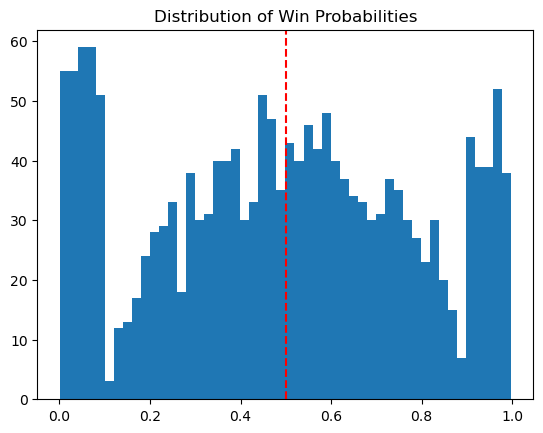

In [55]:
import matplotlib.pyplot as plt

plt.hist(win_prob, bins=50)
plt.axvline(0.5, color='r', linestyle='--')
plt.title('Distribution of Win Probabilities')
plt.show()

In [56]:
for k in range(2, 7):
    gmm_k = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm_k.fit(features)
    print(f"k={k}  BIC: {gmm_k.bic(features):.2f}  AIC: {gmm_k.aic(features):.2f}")

k=2  BIC: -11823.67  AIC: -11927.37
k=3  BIC: -18326.57  AIC: -18484.84
k=4  BIC: -33983.17  AIC: -34196.01
k=5  BIC: -33908.59  AIC: -34176.01
k=6  BIC: -33924.59  AIC: -34246.59


In [57]:
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm.fit(features)

labels = gmm.predict(features)
df_results = pd.DataFrame({
    'win_prob': win_prob,
    'confidence': confidence,
    'model_used': model_used,
    'cluster': labels
})

print(df_results.groupby('cluster').agg({
    'win_prob': 'mean',
    'confidence': 'mean',
    'model_used': lambda x: (x == 'xgb').mean()
}))

         win_prob  confidence  model_used
cluster                                  
0        0.050156    0.899688         1.0
1        0.670866    0.341731         0.0
2        0.949359    0.898719         1.0
3        0.333940    0.332120         0.0


In [58]:
cluster_labels = {
    0: 'Lock (Favorite)',
    2: 'Lock (Underdog)',
    1: 'Likely',
    3: 'Risky'
}

# Sort by win_prob to assign labels dynamically rather than hardcoding
cluster_means = df_results.groupby('cluster')['win_prob'].mean().sort_values(ascending=False)
dynamic_labels = {
    cluster_means.index[0]: 'Lock (Favorite)',
    cluster_means.index[1]: 'Likely',
    cluster_means.index[2]: 'Risky',
    cluster_means.index[3]: 'Lock (Underdog)'
}

df_results['label'] = df_results['cluster'].map(dynamic_labels)

X_xgb_test.columns

Index(['home', 'points_L5_Avg_off', 'assists_L5_Avg_off',
       'reboundsTotal_L5_Avg_off', 'win_L5_Avg_off', 'points_L5_Home_Avg_off',
       'assists_L5_Home_Avg_off', 'reboundsTotal_L5_Home_Avg_off',
       'win_L5_Home_Avg_off', 'points_L5_Away_Avg_off',
       ...
       'opp_off_vs_team_def_ast_rank', 'opp_off_vs_team_def_reb_rank',
       'team_off_vs_opp_def_pts_rank_away',
       'team_off_vs_opp_def_pts_rank_home', 'def_pts_diff_L5',
       'def_ast_diff_L5', 'def_reb_diff_L5', 'def_pts_diff_L10',
       'def_ast_diff_L10', 'def_reb_diff_L10'],
      dtype='object', length=224)